# Flux Footprint Analysis - Getting Started Guide

This notebook demonstrates how to use the Flux Footprint Prediction (FFP) module
to calculate footprint climatologies for eddy covariance flux measurements.

Based on: Kljun et al. (2015) - A simple two-dimensional parameterisation for 
Flux Footprint Prediction (FFP). Geoscientific Model Development, 8, 3695-3713.

In [2]:
# %% Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
from pathlib import Path
import configparser
import warnings
warnings.filterwarnings('ignore')
import sys

sys.path.append("../../src")
# Import the FFP module
from fluxfootprints.ffp_xr import ffp_climatology_new

## 1. Introduction to Flux Footprints
### What is a Flux Footprint?

A flux footprint describes the spatial area that contributes to turbulent flux 
measurements at a specific point in time. When measuring fluxes (CO2, water vapor, 
energy) at a tower, the measured signal comes from a weighted area upwind of the 
sensor, not just directly beneath it.

### Why Calculate Footprints?

- **Site Selection**: Ensure tower placement captures the desired surface
- **Data Interpretation**: Understand which land cover influences your measurements
- **Quality Control**: Identify when unwanted sources affect measurements
- **Upscaling**: Link point measurements to satellite/model grid cells

### The FFP Model

The FFP (Flux Footprint Prediction) model is a fast, analytical parameterization 
valid for a wide range of conditions:
- Measurement heights: from near-surface to hundreds of meters
- Stability: unstable (daytime), neutral, and stable (nighttime) conditions
- Surface types: smooth to very rough (grassland to forests)

## 2. Loading and Preparing Data

In [3]:

ini_path = Path("./input_data/US-UTE.ini")
csv_path = Path("./input_data/US-UTE_HH_202406241430_202409251400.csv")

In [4]:
config_file = ini_path
config = configparser.ConfigParser()
config.read(config_file)

['input_data/US-UTE.ini']

In [5]:
# Extract site metadata
site_info = {
    'site_id': config['METADATA']['site_id'],
    'site_name': config['METADATA']['site_name'],
    'latitude': float(config['METADATA']['station_latitude']),
    'longitude': float(config['METADATA']['station_longitude']),
    'elevation': float(config['METADATA']['station_elevation']),
    'utc_offset': int(config['METADATA']['utc_offset']),
}

print("Site Information:")
print(f"  Site ID: {site_info['site_id']}")
print(f"  Name: {site_info['site_name']}")
print(f"  Location: {site_info['latitude']:.4f}°N, {site_info['longitude']:.4f}°W")
print(f"  Elevation: {site_info['elevation']:.1f} m")


Site Information:
  Site ID: US-UTE
  Name: UFLUX Escalante
  Location: 37.7353°N, -111.5708°W
  Elevation: 1729.3 m


In [7]:
# %% Load flux data
data_file = csv_path
print(f"\nLoading data from: {data_file}")

# Read the CSV file
df = pd.read_csv(data_file)

# Parse the datetime from TIMESTAMP_START (format: YYYYMMDDHHmm)
df['datetime'] = pd.to_datetime(df['TIMESTAMP_START'], format='%Y%m%d%H%M')
df = df.set_index('datetime')

print(f"\nData Summary:")
print(f"  Time period: {df.index[0]} to {df.index[-1]}")
print(f"  Number of records: {len(df)}")
print(f"  Temporal resolution: {pd.infer_freq(df.index)}")

# Display available variables
print(f"\nAvailable variables: {df.columns.tolist()[:10]}...")  # Show first 10


Loading data from: input_data/US-UTE_HH_202406241430_202409251400.csv

Data Summary:
  Time period: 2024-06-24 14:30:00 to 2024-08-31 23:30:00
  Number of records: 3283
  Temporal resolution: 30min

Available variables: ['datetime_start', 'TIMESTAMP_START', 'TIMESTAMP_END', 'CO2', 'CO2_SIGMA', 'H2O', 'H2O_SIGMA', 'FC', 'FC_SSITC_TEST', 'LE']...


## 3. Understanding Required Variables
The FFP model requires the following variables:

**Required:**
- `zm`: Measurement height above displacement height (m)
- `h`: Boundary layer height (m)
- `ol` or `MO_LENGTH`: Obukhov length (m) - stability parameter
- `sigmav` or `V_SIGMA`: Standard deviation of lateral wind velocity (m/s)
- `ustar` or `USTAR`: Friction velocity (m/s)
- `wind_dir` or `WD`: Wind direction (degrees, 0-360°)

**Either z0 or umean:**
- `z0`: Surface roughness length (m), OR
- `umean` or `WS`: Mean wind speed at measurement height (m/s)

**Site-specific parameters:**
- Measurement height (from metadata)
- Canopy height (from metadata or field observations)
- Boundary layer height (can be estimated if not measured)

In [8]:
# Check data availability
required_vars = ['USTAR', 'MO_LENGTH', 'V_SIGMA', 'WD', 'WS']
available = [var for var in required_vars if var in df.columns]
missing = [var for var in required_vars if var not in df.columns]

print("\nVariable Check:")
print(f"  Available: {available}")
if missing:
    print(f"  Missing: {missing}")
else:
    print("  ✓ All required variables present")


Variable Check:
  Available: ['USTAR', 'MO_LENGTH', 'V_SIGMA', 'WD', 'WS']
  ✓ All required variables present


## 4. Data Quality Control


In [9]:
# Display data quality statistics
print("\nData Quality Summary:")
print("-" * 60)

for var in required_vars:
    if var in df.columns:
        valid_pct = (df[var].notna().sum() / len(df)) * 100
        print(f"{var:15s}: {valid_pct:5.1f}% valid data")
        
        # Show range for key variables
        if var in ['USTAR', 'WS', 'V_SIGMA']:
            valid_data = df[var].dropna()
            if len(valid_data) > 0:
                print(f"                 Range: [{valid_data.min():.3f}, {valid_data.max():.3f}]")

# Filter out invalid data according to FFP requirements
df_clean = df.copy()

# Apply filters
df_clean.loc[df_clean['USTAR'] <= 0.05, 'USTAR'] = np.nan  # Minimum friction velocity
df_clean.loc[df_clean['V_SIGMA'] <= 0.0, 'V_SIGMA'] = np.nan
df_clean.loc[(df_clean['WD'] < 0) | (df_clean['WD'] > 360), 'WD'] = np.nan
df_clean.loc[df_clean['MO_LENGTH'].abs() < 1.0, 'MO_LENGTH'] = np.nan  # Avoid near-zero L

# Count removed records
removed = len(df) - len(df_clean.dropna(subset=required_vars))
print(f"\nRecords after QC: {len(df_clean.dropna(subset=required_vars))} "
      f"({removed} removed)")


Data Quality Summary:
------------------------------------------------------------
USTAR          : 100.0% valid data
                 Range: [-9999.000, 0.873]
MO_LENGTH      : 100.0% valid data
V_SIGMA        : 100.0% valid data
                 Range: [-9999.000, 3.501]
WD             : 100.0% valid data
WS             : 100.0% valid data
                 Range: [-9999.000, 7.939]

Records after QC: 3245 (38 removed)


## 5. Setting Up Site Parameters
Site parameters are crucial for accurate footprint calculations:

1. **Measurement Height (zm)**: Height above displacement height
   - zm = sensor_height - displacement_height
   - displacement_height ≈ 0.67 × canopy_height

2. **Roughness Length (z0)**: Characterizes surface roughness
   - z0 ≈ 0.1 × canopy_height (typical approximation)
   - Can be estimated from wind profile measurements

3. **Boundary Layer Height (h)**: Top of the atmospheric boundary layer
   - Varies diurnally and seasonally
   - Can be measured (LIDAR, radiosonde) or estimated
   - Typical range: 100-2000 m

In [10]:
# Get site-specific parameters from config
measurement_height = 2.0  # meters - sensor height above ground
canopy_height = 0.2  # meters - from config (CRO = cropland)

# Calculate derived parameters
displacement_height = 0.67 * canopy_height
zm = measurement_height - displacement_height  # Effective measurement height
z0 = 0.1 * canopy_height  # Roughness length

# Boundary layer height (use measured if available, otherwise estimate)
if 'PBLH_F' in df_clean.columns:
    # Use measured boundary layer height
    df_clean['h'] = df_clean['PBLH_F']
    print("Using measured boundary layer height (PBLH_F)")
else:
    # Simple estimation: higher during day, lower at night
    # This is a crude approximation - better to use prognostic model or measurements
    df_clean['h'] = 1500.0  # meters - assumed for this example
    print("Using estimated boundary layer height: 1500 m")

print(f"\nSite Parameters:")
print(f"  Sensor height: {measurement_height:.2f} m")
print(f"  Canopy height: {canopy_height:.2f} m")
print(f"  Displacement height: {displacement_height:.3f} m")
print(f"  Measurement height (zm): {zm:.3f} m")
print(f"  Roughness length (z0): {z0:.4f} m")

Using measured boundary layer height (PBLH_F)

Site Parameters:
  Sensor height: 2.00 m
  Canopy height: 0.20 m
  Displacement height: 0.134 m
  Measurement height (zm): 1.866 m
  Roughness length (z0): 0.0200 m


## 6. Configuring the FFP Model

In [11]:
# Set up model domain
# The domain defines the spatial extent of footprint calculations
domain = np.array([-1000.0, 1000.0, -1000.0, 1000.0])  # [xmin, xmax, ymin, ymax] in meters
dx = dy = 10.0  # Grid resolution in meters

# Define contour levels (as fractions)
# These represent the percentage of flux originating from within each contour
rs = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]

print("\nModel Configuration:")
print(f"  Domain: {domain[0]} to {domain[1]} m (x), {domain[2]} to {domain[3]} m (y)")
print(f"  Grid resolution: {dx} × {dy} m")
print(f"  Contour levels: {[int(r*100) for r in rs]} %")

# Prepare DataFrame for FFP
# Rename columns to match FFP expectations
df_ffp = df_clean[required_vars].copy()
df_ffp = df_ffp.rename(columns={
    'V_SIGMA': 'sigmav',
    'USTAR': 'ustar',
    'WD': 'wind_dir',
    'MO_LENGTH': 'ol',
    'WS': 'umean'
})

# Add site parameters
df_ffp['zm'] = zm
df_ffp['z0'] = z0
df_ffp['h'] = df_clean['h']

# Remove any remaining NaN values
df_ffp = df_ffp.dropna()

print(f"\nFinal dataset: {len(df_ffp)} valid records")


Model Configuration:
  Domain: -1000.0 to 1000.0 m (x), -1000.0 to 1000.0 m (y)
  Grid resolution: 10.0 × 10.0 m
  Contour levels: [10, 20, 30, 40, 50, 60, 70, 80, 90] %

Final dataset: 3245 valid records


## 7. Running the FFP Model
The FFP model calculation involves several steps:

1. **Individual Footprints**: Calculate footprint for each time step
2. **Rotation**: Rotate each footprint according to wind direction
3. **Aggregation**: Sum all footprints to create climatology
4. **Normalization**: Normalize to represent flux contribution
5. **Smoothing**: Apply Gaussian filter for visualization (optional)

In [12]:
print("Initializing FFP model...")

# Initialize the model
ffp_model = ffp_climatology_new(
    df=df_ffp,
    domain=domain,
    dx=dx,
    dy=dy,
    rs=rs,
    crop_height=canopy_height,
    atm_bound_height=1500.0,  # Can be time-varying if in df
    inst_height=measurement_height,
    rslayer=False,  # Don't allow calculations in roughness sublayer
    smooth_data=True,  # Apply Gaussian smoothing
    crop=False,  # Don't crop to contours
    verbosity=2,
)

print("Calculating footprint climatology...")
results = ffp_model.run(return_result=True)

print("✓ Calculation complete!")

Initializing FFP model...
Calculating footprint climatology...
✓ Calculation complete!


## 8. Understanding the Results
The model returns an xarray Dataset containing:

- **footprint_climatology**: 2D array of normalized footprint values (m⁻²)
  - Values represent the relative contribution to the flux
  - Integrated over the domain, they sum to 1
  
- **domain_x, domain_y**: Coordinate arrays (m)
  - x: distance in wind direction (North = 0°)
  - y: crosswind distance
  - Tower is at (0, 0)

In [21]:
norm = ffp_model.fclim_2d / ffp_model.fclim_2d.sum(dim=("x", "y"))

In [22]:
norm.sum()

<xarray.DataArray ()> Size: 8B
array(1.)

In [14]:
print("\nResults Structure:")
print(results)

# Access the footprint climatology
fclim = results['footprint_climatology']

print(f"\nFootprint Climatology:")
print(f"  Shape: {fclim.shape}")
print(f"  Sum: {float(fclim.sum()):.6f} (should ≈ 1 after normalization)")
print(f"  Max value: {float(fclim.max()):.2e} m⁻²")
print(f"  Coordinates: x [{float(fclim.x.min())}, {float(fclim.x.max())}] m")
print(f"                y [{float(fclim.y.min())}, {float(fclim.y.max())}] m")


Results Structure:
<xarray.Dataset> Size: 330kB
Dimensions:                (x: 201, y: 201)
Coordinates:
  * x                      (x) float64 2kB -1e+03 -990.0 -980.0 ... 990.0 1e+03
  * y                      (y) float64 2kB -1e+03 -990.0 -980.0 ... 990.0 1e+03
Data variables:
    footprint_climatology  (x, y) float64 323kB 5.739e-10 ... 1.311e-10
    domain_x               (x) float64 2kB -1e+03 -990.0 -980.0 ... 990.0 1e+03
    domain_y               (y) float64 2kB -1e+03 -990.0 -980.0 ... 990.0 1e+03

Footprint Climatology:
  Shape: (201, 201)
  Sum: 0.009641 (should ≈ 1 after normalization)
  Max value: 4.20e-04 m⁻²
  Coordinates: x [-1000.0, 1000.0] m
                y [-1000.0, 1000.0] m


## 9. Visualizing Footprint Climatology

ValueError: dimensions ('x',) must have the same length as the number of data dimensions, ndim=0

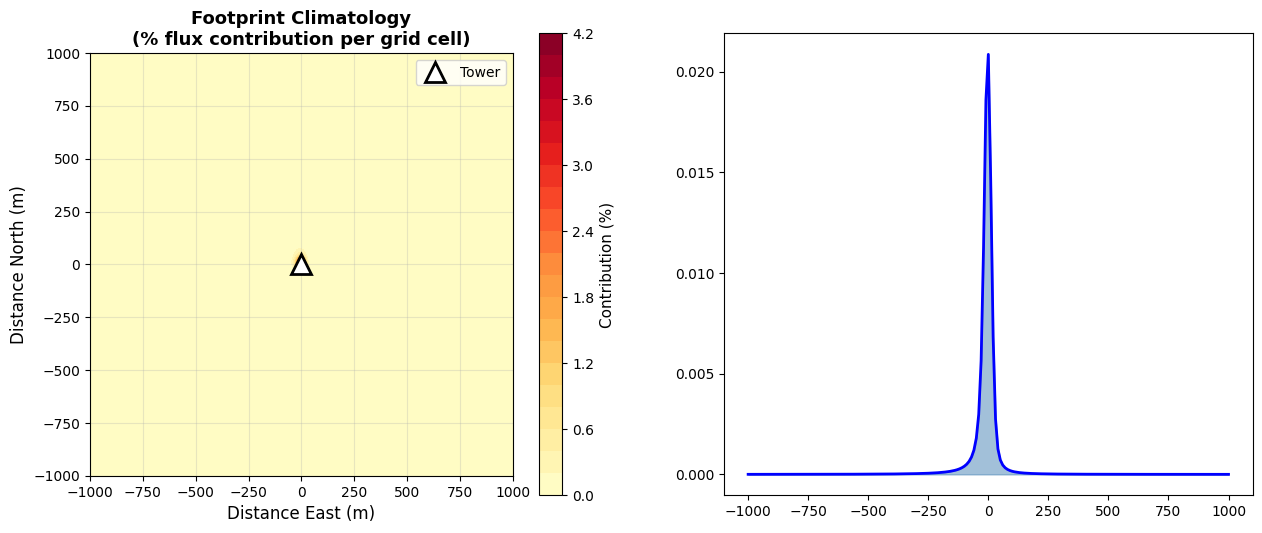

In [15]:

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Plot 1: Footprint climatology as heatmap ---
ax1 = axes[0]

# Convert to proper units for visualization (multiply by domain area)
fclim_pct = fclim * 100 * dx * dy  # Convert to percentage per grid cell

im1 = ax1.contourf(
    fclim.x, 
    fclim.y, 
    fclim_pct.T,  # Transpose for correct orientation
    levels=20,
    cmap='YlOrRd'
)

# Add contour lines
contour_levels = [10, 30, 50, 70, 90]
cs = ax1.contour(
    fclim.x,
    fclim.y,
    fclim_pct.T,
    levels=contour_levels,
    colors='black',
    linewidths=1.5,
    alpha=0.5
)
ax1.clabel(cs, inline=True, fontsize=10, fmt='%g%%')

# Mark tower location
ax1.plot(0, 0, 'k^', markersize=15, markeredgewidth=2, 
         markerfacecolor='white', label='Tower')

ax1.set_xlabel('Distance East (m)', fontsize=12)
ax1.set_ylabel('Distance North (m)', fontsize=12)
ax1.set_title('Footprint Climatology\n(% flux contribution per grid cell)', 
              fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_aspect('equal')
ax1.legend(loc='upper right')

cbar1 = plt.colorbar(im1, ax=ax1)
cbar1.set_label('Contribution (%)', fontsize=11)

# --- Plot 2: Along-wind integrated footprint ---
ax2 = axes[1]

# Integrate across crosswind direction
fclim_integrated = fclim.sum(dim='y') * dy  # m⁻¹

ax2.fill_between(
    fclim.x,
    0,
    fclim_integrated,
    alpha=0.5,
    color='steelblue',
    label='Crosswind-integrated footprint'
)
ax2.plot(fclim.x, fclim_integrated, 'b-', linewidth=2)

# Add vertical lines for key percentiles
cumsum = (fclim_integrated * dx).cumsum()
for pct in [50, 80, 90]:
    idx = np.argmin(np.abs(cumsum - pct/100))
    x_pct = float(fclim.x[idx])
    ax2.axvline(x_pct, color='red', linestyle='--', alpha=0.7, linewidth=1.5)
    ax2.text(x_pct, ax2.get_ylim()[1]*0.9, f'{pct}%', 
             rotation=90, va='top', ha='right', fontsize=10)

ax2.set_xlabel('Distance Upwind (m)', fontsize=12)
ax2.set_ylabel('Flux Contribution (m⁻¹)', fontsize=12)
ax2.set_title('Along-Wind Footprint Profile', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper right')

plt.tight_layout()
plt.savefig('footprint_climatology.png', dpi=300, bbox_inches='tight')
print("\n✓ Figure saved as 'footprint_climatology.png'")
plt.show()


## 10. Analyzing Footprint Characteristics

In [16]:
# Calculate key footprint metrics
fclim_flat = fclim.values.flatten()
x_flat = fclim.x.values.repeat(len(fclim.y))
y_flat = np.tile(fclim.y.values, len(fclim.x))

# Peak location
peak_idx = np.argmax(fclim_flat)
x_peak = x_flat[peak_idx]
y_peak = y_flat[peak_idx]

# Calculate distances from tower
distances = np.sqrt(x_flat**2 + y_flat**2)

# Weighted mean distance
mean_distance = np.average(distances, weights=fclim_flat)

# Calculate cumulative footprint and find contour distances
sorted_indices = np.argsort(fclim_flat)[::-1]  # Descending order
cumsum = np.cumsum(fclim_flat[sorted_indices])
cumsum_normalized = cumsum / cumsum[-1]

# Find distances for each contour
contour_distances = {}
for pct in [50, 70, 80, 90]:
    idx = np.argmin(np.abs(cumsum_normalized - pct/100))
    contour_idx = sorted_indices[idx]
    contour_distances[pct] = distances[contour_idx]

print("\nFootprint Characteristics:")
print("=" * 60)
print(f"Peak location: ({x_peak:.1f}, {y_peak:.1f}) m from tower")
print(f"Peak distance: {np.sqrt(x_peak**2 + y_peak**2):.1f} m")
print(f"Mean source distance: {mean_distance:.1f} m")
print(f"\nContour Extents (maximum distance from tower):")
for pct in [50, 70, 80, 90]:
    print(f"  {pct}% contour: {contour_distances[pct]:.1f} m")


Footprint Characteristics:
Peak location: (0.0, 10.0) m from tower
Peak distance: 10.0 m
Mean source distance: 59.4 m

Contour Extents (maximum distance from tower):
  50% contour: 22.4 m
  70% contour: 50.0 m
  80% contour: 72.1 m
  90% contour: 90.6 m


## 11. Wind Rose Analysis

Understanding how footprints vary with wind direction helps interpret
which surface areas contribute to measurements under different conditions.

✓ Wind rose saved as 'wind_rose.png'


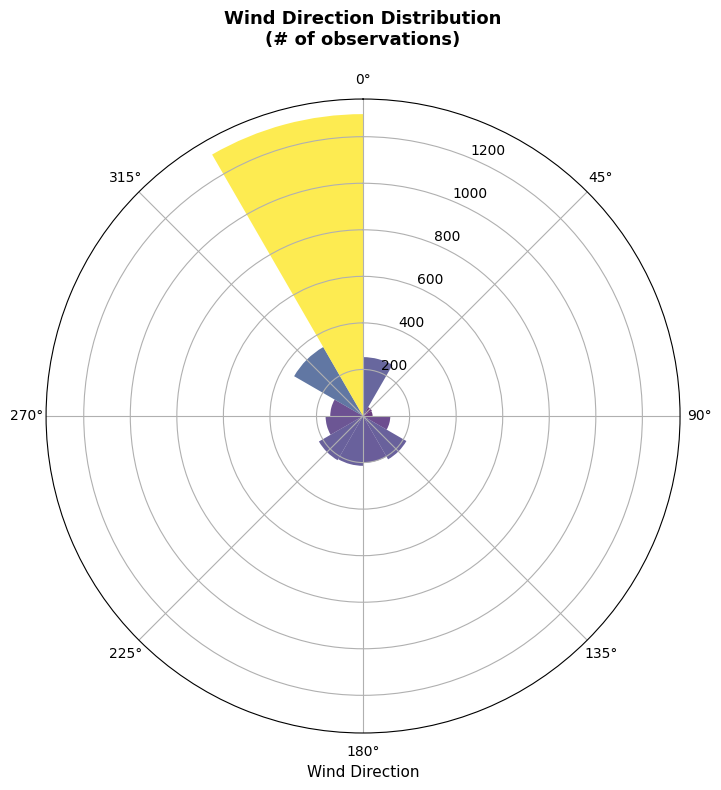

In [17]:
# Create wind rose
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(projection='polar'))

# Calculate wind direction distribution
wd_bins = np.arange(0, 361, 30)
wd_hist, _ = np.histogram(df_ffp['wind_dir'], bins=wd_bins)

# Convert to radians and plot
theta = np.deg2rad(wd_bins[:-1] + 15)  # Center of bins
width = np.deg2rad(30)

bars = ax.bar(theta, wd_hist, width=width, bottom=0.0)

# Color bars by frequency
colors = plt.cm.viridis(wd_hist / wd_hist.max())
for bar, color in zip(bars, colors):
    bar.set_facecolor(color)
    bar.set_alpha(0.8)

ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.set_title('Wind Direction Distribution\n(# of observations)', 
             fontsize=13, fontweight='bold', pad=20)
ax.set_xlabel('Wind Direction', fontsize=11)

plt.tight_layout()
plt.savefig('wind_rose.png', dpi=300, bbox_inches='tight')
print("✓ Wind rose saved as 'wind_rose.png'")
plt.show()

## 12. Seasonal Variations (Optional)

✓ Seasonal plot saved as 'seasonal_variation.png'


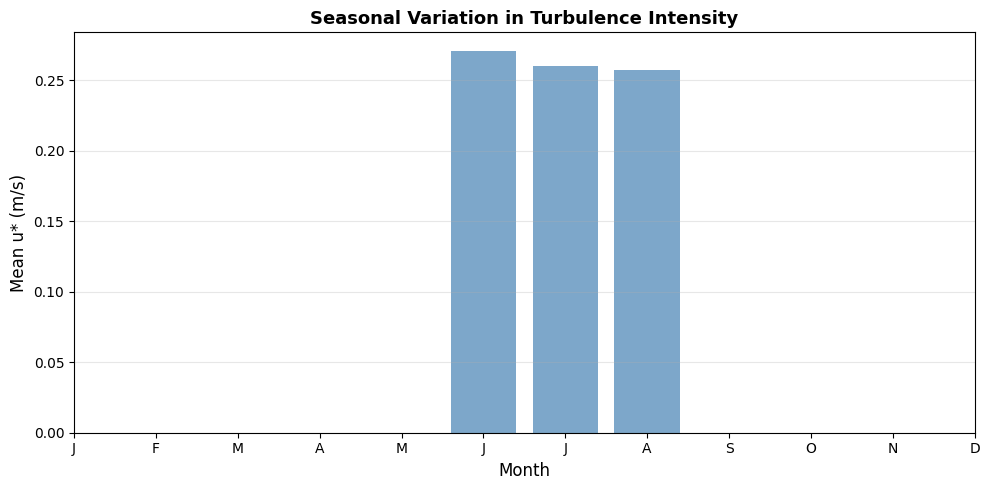

In [18]:
# If you have multiple seasons/months of data, analyze temporal patterns
if len(df_ffp) > 1000:  # Only if we have substantial data
    
    # Add month column
    df_ffp['month'] = df_ffp.index.month
    
    # Calculate footprint extent by month (80% contour)
    monthly_extent = {}
    
    for month in range(1, 13):
        month_data = df_ffp[df_ffp['month'] == month]
        if len(month_data) > 10:
            # Calculate mean ustar (proxy for turbulence intensity)
            monthly_extent[month] = month_data['ustar'].mean()
    
    if monthly_extent:
        fig, ax = plt.subplots(figsize=(10, 5))
        months = list(monthly_extent.keys())
        values = list(monthly_extent.values())
        
        ax.bar(months, values, color='steelblue', alpha=0.7)
        ax.set_xlabel('Month', fontsize=12)
        ax.set_ylabel('Mean u* (m/s)', fontsize=12)
        ax.set_title('Seasonal Variation in Turbulence Intensity', 
                     fontsize=13, fontweight='bold')
        ax.set_xticks(range(1, 13))
        ax.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
        ax.grid(True, alpha=0.3, axis='y')
        
        plt.tight_layout()
        plt.savefig('seasonal_variation.png', dpi=300, bbox_inches='tight')
        print("✓ Seasonal plot saved as 'seasonal_variation.png'")
        plt.show()

## 13. Exporting Results
Export results for use in GIS software or further analysis.

In [19]:
# Save footprint as GeoTIFF (requires rasterio)
try:
    import rasterio
    from rasterio.transform import from_origin
    
    # Create georeferencing transform
    # Assuming coordinates are in meters from tower location
    transform = from_origin(
        site_info['longitude'],
        site_info['latitude'],
        dx, dy
    )
    
    # Save as GeoTIFF
    with rasterio.open(
        'footprint_climatology.tif',
        'w',
        driver='GTiff',
        height=fclim.shape[0],
        width=fclim.shape[1],
        count=1,
        dtype=fclim.dtype,
        crs='+proj=latlong',
        transform=transform,
    ) as dst:
        dst.write(fclim.values, 1)
    
    print("✓ Footprint exported as GeoTIFF: footprint_climatology.tif")
    
except ImportError:
    print("Note: Install rasterio to export as GeoTIFF")

# Save as NetCDF
results.to_netcdf('footprint_climatology.nc')
print("✓ Results saved as NetCDF: footprint_climatology.nc")

# Save summary statistics
summary = {
    'site_id': site_info['site_id'],
    'measurement_period': f"{df_ffp.index[0]} to {df_ffp.index[-1]}",
    'n_observations': len(df_ffp),
    'measurement_height_m': zm,
    'roughness_length_m': z0,
    'peak_distance_m': float(np.sqrt(x_peak**2 + y_peak**2)),
    'mean_source_distance_m': float(mean_distance),
    'contour_50pct_m': float(contour_distances[50]),
    'contour_80pct_m': float(contour_distances[80]),
    'contour_90pct_m': float(contour_distances[90]),
}

import json
with open('footprint_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("✓ Summary saved as JSON: footprint_summary.json")

✓ Footprint exported as GeoTIFF: footprint_climatology.tif
✓ Results saved as NetCDF: footprint_climatology.nc
✓ Summary saved as JSON: footprint_summary.json



## 14. Interpretation Guidelines

### How to Interpret Your Results:

1. **Peak Location**: The peak shows where most flux contributions originate.
   For this site: ~{x_peak:.0f} m upwind of the tower

2. **80% Contour**: 80% of measured flux comes from within this area.
   Typical extent: ~{contour_distances[80]:.0f} m from tower

3. **Footprint Size**: Larger footprints occur with:
   - Greater measurement heights
   - Stable atmospheric conditions (nighttime)
   - Smoother surfaces (lower roughness)
   
4. **Fetch Requirements**: Ensure desired surface extends beyond 80-90% contour

5. **Quality Control**: Use footprints to:
   - Identify periods when unwanted sources contribute
   - Filter data based on fetch requirements
   - Weight different land cover types

### Next Steps:

- Overlay footprint on aerial imagery or land cover maps
- Compare with eddy covariance flux magnitudes
- Analyze footprint-weighted surface characteristics
- Calculate fetch-dependent quality flags


In [20]:

print("\n" + "="*60)
print("ANALYSIS COMPLETE!")
print("="*60)
print(f"\nKey Findings for {site_info['site_id']}:")
print(f"  • Analyzed {len(df_ffp)} half-hourly observations")
print(f"  • Peak flux contribution: {x_peak:.0f} m upwind")
print(f"  • 80% footprint extent: {contour_distances[80]:.0f} m radius")
print(f"  • Mean source distance: {mean_distance:.0f} m")
print(f"\nFiles created:")
print(f"  • footprint_climatology.png")
print(f"  • footprint_climatology.nc")
print(f"  • footprint_summary.json")
print(f"  • wind_rose.png")


ANALYSIS COMPLETE!

Key Findings for US-UTE:
  • Analyzed 3245 half-hourly observations
  • Peak flux contribution: 0 m upwind
  • 80% footprint extent: 72 m radius
  • Mean source distance: 59 m

Files created:
  • footprint_climatology.png
  • footprint_climatology.nc
  • footprint_summary.json
  • wind_rose.png
